# Worked example : optimizing turner noise

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

One genetic-algorithm optimization from beginning to end, on the smallest possible target : **two**
parameters of the `explorer` model's turner module - its **input noise** and its **output noise** -
fitted so that simulated turning resembles the turning of real larvae.

Two parameters is not a limitation of the method, it is the point. A narrow space converges in
minutes rather than hours, and, more importantly, the result is interpretable : if the fit improves,
you know exactly what changed.

Every simulation below imitates the reference dataset's arena and its per-agent body length through
`ExpConf.imitation_exp`, and matches its duration and timestep, so every video and every dataset is
directly comparable with the real recording.

**What comes out of it**

For both the whole population and a single larva : a *before* video (real vs. unoptimized
`explorer`), an *after* video (real vs. optimized vs. unoptimized), a GA progress plot, a model-diff
table, and a final model-evaluation comparison.

**What you will be able to do afterwards**

- Set up an optimization that varies named parameters rather than whole modules.
- Match a simulation to a reference dataset without configuring the arena by hand.
- Read a GA progress curve and a model diff.
- Confirm an improvement with an evaluation instead of asserting it from the videos.

**Prerequisites** : [Genetic algorithm optimization](genetic_algorithm_optimization.ipynb) and
[Model evaluation](model_evaluation.ipynb).

**Cost** : substantial when switched on. The GA alone is 20 generations x 10 agents = 200
simulations; the videos add several minutes of rendering each.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_VIDEO_DEMOS` | `False` | every replay and dish simulation that writes a video |
| `RUN_GA_DEMO` | `False` | the genetic algorithm and the plots derived from it |
| `RUN_EVAL_DEMO` | `False` | the final model evaluation |

**Where the output goes.** Each execution gets its own folder, `MEDIA_DIR`, named after the run
timestamp, so a single run's videos, plots, GA progress CSV and evaluation figures land together
instead of being scattered across the package's default `SimGroup/{exp,ga,eval}_runs/...`
locations. The file names quoted in italics below are relative to that folder.

In [1]:
%matplotlib inline

%load_ext param.ipython
import datetime
import larvaworld as lw
from larvaworld.lib import reg, util
from larvaworld.lib.sim import ReplayRun, ExpRun
from larvaworld.lib.sim.genetic_algorithm import GAlauncher
from larvaworld.lib.sim.model_evaluation import EvalRun
from larvaworld.lib.reg.generators import ReplayConf, ExpConf
from larvaworld.lib.util.combining import combine_videos

lw.VERBOSE = 1

# Tutorial safety switches (avoid heavy compute / media generation by default)
RUN_VIDEO_DEMOS = False
RUN_GA_DEMO = False
RUN_EVAL_DEMO = False

# One folder per notebook execution: every ExpRun/GAlauncher/ReplayRun/
# EvalRun call below is given an explicit `dir=`/`media_dir=` under
# MEDIA_DIR, so a single run's entire output (videos, plots, GA CSV,
# eval plots) lands together instead of being scattered across
# SimGroup/{exp,ga,eval}_runs/... and a shared, overwritten media folder.
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
MEDIA_DIR = f"./media/ga_turner_noise/{RUN_ID}"
OLD_MODEL_ID = "explorer"
NEW_MODEL_ID = "explorer_optimized_turner"

# The GA optimization loop uses a shorter proxy duration for fitness
# evaluation (optimizing against the full multi-minute recording for
# every genome of every generation would be prohibitively slow). The
# comparison videos below all use the reference dataset's own, full,
# matched duration/dt.
GA_DURATION_MIN = 0.3
GA_NAGENTS = 10
GA_NELITS = 2
GA_NGENERATIONS = 20

Welcome to the param IPython extension! (https://param.holoviz.org/)
Available magics: %params


Initializing larvaworld registry


Registry configured!


## Where simulated datasets are stored

Every simulation run below is given an explicit `id` and an explicit
`dir=` under `MEDIA_DIR` (one folder per notebook execution, named by
`RUN_ID`), so a single run's entire output -- videos, plots, the GA's
per-generation CSV, and the model-evaluation plots -- lands together
instead of being scattered across the package's default
`SimGroup/{exp,ga,eval}_runs/...` locations. `ExpRun` stores its output
under `{dir}/data/{group_id}` (one subfolder per larva group) --
printed for each run below. No registry entry is created unless a
`refID` is set, so a simulated dataset is retrieved by directory:
`LarvaDataset(dir=<that path>)`. `GAlauncher` stores under `{dir}/`,
with its per-generation genome CSV directly inside.

In [2]:
refID = reg.default_refID
d = reg.loadRef(refID)
d.load()

print(f"Reference dataset: {refID}")
print(f"N={d.config.N} agents, color={d.config.color!r}")
print(f"dt={d.config.dt}s, duration={d.config.duration:.2f} min")
print(
    f"arena={d.config.env_params.arena.dims}, shape={d.config.env_params.arena.geometry}"
)
print(f"mean body length={d.e['length'].mean():.4f} m")

Loaded existing conf larvae_single
Loaded stored reference dataset : Chris.larvae_single
Loaded existing conf TopDown-2023-07-05
Loaded stored reference dataset : DeepLabCut.TopDown-2023-07-05
Loaded existing conf TopDown-2024-02-17
Loaded stored reference dataset : DeepLabCut.TopDown-2024-02-17
Loaded existing conf Fed
Loaded stored reference dataset : FeedingState.Fed
Loaded existing conf Starved
Loaded stored reference dataset : FeedingState.Starved
Loaded existing conf Sucrose
Loaded stored reference dataset : FeedingState.Sucrose
Loaded existing conf pooled


Loaded stored reference dataset : FreeExploration.pooled
Loaded existing conf single_dish
Loaded stored reference dataset : FreeExploration.single_dish
Loaded existing conf 30controls
Loaded stored reference dataset : exploration.30controls
Loaded existing conf dish01
Loaded stored reference dataset : exploration.dish01
Loaded existing conf dish02
Loaded stored reference dataset : exploration.dish02
Loaded existing conf 30controls
Loaded stored reference dataset : exploration.30controls


Reference dataset: exploration.30controls
N=30 agents, color='blue'
dt=0.0625s, duration=3.00 min
arena=(0.15, 0.15), shape=circular
mean body length=0.0039 m


## Step 1 -- Reference dataset replay (full population)

Replay the reference dataset in full, reconstructing each larva's body
with 2 segments.

In [3]:
if RUN_VIDEO_DEMOS:
    p1 = ReplayConf(refID=refID, draw_Nsegs=2).nestedConf
    screen_kws1 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_1_reference",
    }
    ReplayRun(
        parameters=p1,
        id=f"{refID}_replay_full",
        dir=f"{MEDIA_DIR}/rep1",
        screen_kws=screen_kws1,
    ).run()

## Reconstructed-2seg reference dataset

`draw_Nsegs=2` reconstructs a larva's body from just its front/rear
orientation vectors -- `LarvaDataset.reconstruct_at_Nsegs(2)` recomputes
a dataset's angular kinematics from that same coarse 2-vector body, so
the reference dataset's real data and its 2-segment reconstruction can
be compared directly.

***** Dataset 30controls_2seg stored.-----
Reconstructed dataset: id='30controls_2seg', dir=./media/ga_turner_noise/20260820_095257/data/exploration_30controls_2seg


Plot angular_pars_real_vs_reconstructed.pdf saved as ./media/ga_turner_noise/20260820_095257/distro\angular_pars_real_vs_reconstructed.pdf


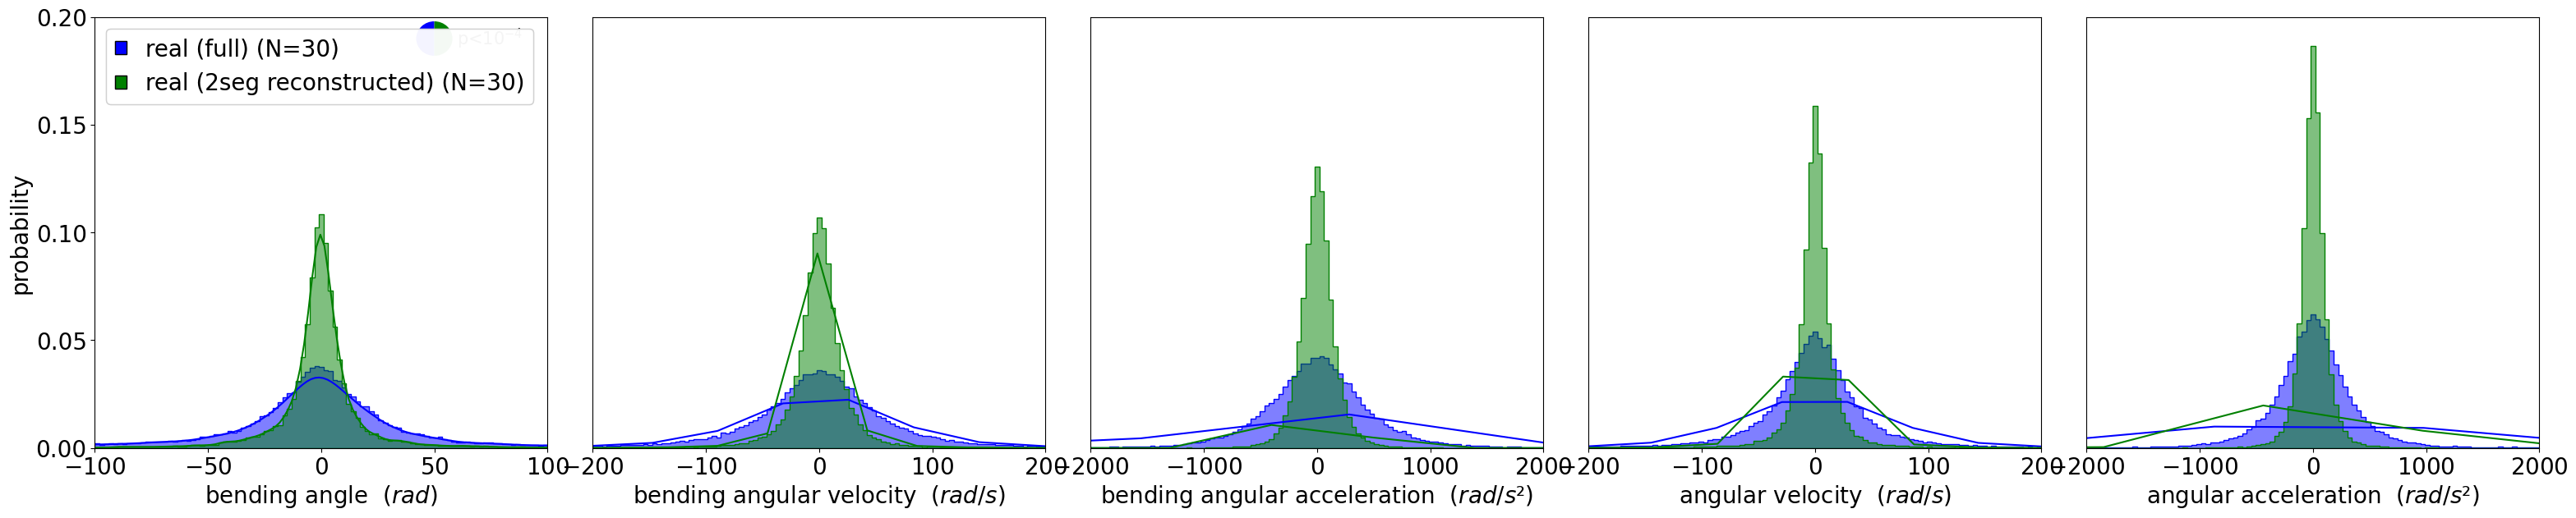

In [4]:
d_2seg = d.reconstruct_at_Nsegs(
    2, new_dir=f"{MEDIA_DIR}/data/{refID.replace('.', '_')}_2seg"
)
print(f"Reconstructed dataset: id={d_2seg.id!r}, dir={d_2seg.dir}")

fig_recon = reg.graphs.run(
    "angular pars",
    datasets=[d, d_2seg],
    labels=["real (full)", "real (2seg reconstructed)"],
    save_to=MEDIA_DIR,
    save_as="angular_pars_real_vs_reconstructed",
)
fig_recon

*Output file : `angular_pars_real_vs_reconstructed.pdf`*

The 2-segment reconstruction uses a coarser front/rear vector split
than the original tracking's own (smoother, more finely-tuned)
front/rear vectors, so some reduction in variability is expected;
distributions should stay broadly similar in shape and location.

## Step 2 -- "Old" model dish simulation (full population, matched)

`ExpConf.imitation_exp` imitates the reference dataset's arena and
per-agent body length automatically.

In [5]:
old_conf = ExpConf.imitation_exp(refID, mID=OLD_MODEL_ID).nestedConf

if RUN_VIDEO_DEMOS:
    screen_kws2 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_2_old_dish",
    }
    r_old = ExpRun(
        parameters=old_conf,
        id="ga_turner_old_dish",
        dir=f"{MEDIA_DIR}/exp_runs/old_dish",
        screen_kws=screen_kws2,
        store_data=True,
    )
    r_old.simulate()
    print(f"Old-model dataset: {r_old.datasets[0].id!r} at {r_old.datasets[0].dir}")

Loaded existing conf 30controls


## Step 3 -- Side-by-side #1: reference vs. old-model dish

In [6]:
if RUN_VIDEO_DEMOS:
    combine_videos(
        file_dir=MEDIA_DIR,
        save_as="video_side_by_side_1_reference_vs_old.mp4",
        files=[
            f"{MEDIA_DIR}/video_1_reference.mp4",
            f"{MEDIA_DIR}/video_2_old_dish.mp4",
        ],
    )

*Output file : `video_side_by_side_1_reference_vs_old.mp4`*

At the population level, the two are expected to differ mainly in
**turning behavior** -- the default `explorer` turner hasn't been fit
to this dataset yet.

## Step 4 -- Focused single-larva replays

The real replay selects the reference dataset's most-completely-tracked
larva. The "old"-model replay reuses the dish simulation above -- no
separate `tethered` simulation -- selecting one agent out of the
group-level dataset and tethering it to the arena center exactly like
the real one.

In [7]:
xy_cols = util.nam.xy(d.config.point)
nan_counts = d.s[xy_cols[0]].isna().groupby(level="AgentID").sum()
best_agent_idx = list(d.agent_ids).index(nan_counts.idxmin())

if RUN_VIDEO_DEMOS:
    p3 = ReplayConf(
        refID=refID,
        agent_ids=[best_agent_idx],
        close_view=True,
        fix_point=6,
        draw_Nsegs=2,
    ).nestedConf
    screen_kws3 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_3_reference_focused",
    }
    ReplayRun(
        parameters=p3,
        id=f"{refID}_replay_focused",
        dir=f"{MEDIA_DIR}/rep3",
        screen_kws=screen_kws3,
    ).run()

    d_old_group = r_old.datasets[0]
    p4 = ReplayConf(
        refDir=d_old_group.config.dir,
        agent_ids=[0],
        close_view=True,
        fix_point=0,
        draw_Nsegs=2,
    ).nestedConf
    screen_kws4 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_4_old_focused",
    }
    ReplayRun(
        parameters=p4,
        dataset=d_old_group,
        id="ga_turner_old_focused_replay",
        dir=f"{MEDIA_DIR}/rep4",
        screen_kws=screen_kws4,
    ).run()

## Step 5 -- Side-by-side #2: reference (focused) vs. old-model (focused)

In [8]:
if RUN_VIDEO_DEMOS:
    combine_videos(
        file_dir=MEDIA_DIR,
        save_as="video_side_by_side_2_reference_vs_old_focused.mp4",
        files=[
            f"{MEDIA_DIR}/video_3_reference_focused.mp4",
            f"{MEDIA_DIR}/video_4_old_focused.mp4",
        ],
    )

*Output file : `video_side_by_side_2_reference_vs_old_focused.mp4`*

Focusing on a single larva makes the turning-behavior mismatch easier
to see directly -- this is what the GA optimization below addresses.

## Step 6 -- Angular-parameter comparison: real vs. reconstructed vs. old-model

In [9]:
if RUN_VIDEO_DEMOS:
    fig_pre = reg.graphs.run(
        "angular pars",
        datasets=[d, d_2seg, r_old.datasets[0]],
        labels=["real", "real (2seg)", "old model"],
        save_to=MEDIA_DIR,
        save_as="angular_pars_real_vs_old",
    )
    fig_pre

*Output file : `angular_pars_real_vs_old.pdf`*

## Step 7 -- GA optimization: turner input/output noise only

`SpaceDict`/`GAselector` normally build the optimization space from an
*entire* module and exclude Effector-level params (`input_noise`,
`output_noise`) by design. `include_effector_params=True` +
`space_pkeys=[...]` narrow that down to exactly the two noise
parameters, with no manual space construction needed.

In [10]:
p_ga = reg.conf.Ga.expand("exploration")  # already targets this refID, dt matches
p_ga.ga_select_kws.update(
    base_model=OLD_MODEL_ID,
    bestConfID=NEW_MODEL_ID,
    space_mkeys=["turner"],
    include_effector_params=True,
    space_pkeys=["input_noise", "output_noise"],
    Nagents=GA_NAGENTS,
    Nelits=GA_NELITS,
    Ngenerations=GA_NGENERATIONS,
)

ga = GAlauncher(
    parameters=p_ga,
    duration=GA_DURATION_MIN,
    dir=f"{MEDIA_DIR}/ga_run",
    screen_kws={"show_display": False},
    store_data=True,
)

print("Optimization space:", ga.selector.space_ks)
%params ga.selector
print(
    f"Ngenerations={ga.selector.Ngenerations}, Nagents={ga.selector.Nagents}, generation duration={GA_DURATION_MIN} min"
)

Loaded existing conf 30controls


Loaded stored reference dataset : exploration.30controls
Optimization space: ['brain.turner.input_noise', 'brain.turner.output_noise']
Ngenerations=20, Nagents=10, generation duration=0.3 min


## Step 8 -- Run the GA

In [11]:
if RUN_GA_DEMO:
    best = ga.simulate()
    print(f"Best fitness: {ga.best_fitness}")
    print(f"Optimized turner config: {ga.best_genome.mConf.brain.turner}")
    print(f"Per-generation results stored at: {ga.data_dir}/{NEW_MODEL_ID}.csv")

## Step 9 -- The optimized model is saved automatically

`bestConfID` (set above) makes the GA launcher register the current
best genome's model under that ID every time a new best is found -- no
separate save step is required.

In [12]:
if RUN_GA_DEMO:
    print(NEW_MODEL_ID in reg.conf.Model.confIDs)

## GA progress across generations

In [13]:
if RUN_GA_DEMO:
    import pandas as pd

    df_progress = pd.read_csv(f"{ga.data_dir}/{NEW_MODEL_ID}.csv")
    fig_progress = reg.graphs.run(
        "ga progress",
        df=df_progress,
        ks=["input_noise", "output_noise"],
        module="turner",
        save_to=MEDIA_DIR,
        save_as="ga_progress",
    )
    fig_progress

*Output file : `ga_progress.pdf`*

## Model diff: old vs. optimized turner

In [14]:
if RUN_GA_DEMO:
    fig_diff = reg.graphs.run(
        "model diff",
        mIDs=[OLD_MODEL_ID, NEW_MODEL_ID],
        save_to=MEDIA_DIR,
        save_as="model_diff_old_vs_optimized",
    )
    fig_diff

*Output file : `model_diff_old_vs_optimized.pdf`*

## Step 10 -- Final simulation with the optimized model

In [15]:
if RUN_VIDEO_DEMOS and RUN_GA_DEMO:
    new_conf = ExpConf.imitation_exp(refID, mID=NEW_MODEL_ID).nestedConf
    screen_kws5 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_5_new_dish",
    }
    r_new = ExpRun(
        parameters=new_conf,
        id="ga_turner_new_dish",
        dir=f"{MEDIA_DIR}/exp_runs/new_dish",
        screen_kws=screen_kws5,
        store_data=True,
    )
    r_new.simulate()
    print(f"New-model dataset: {r_new.datasets[0].id!r} at {r_new.datasets[0].dir}")

    d_new_group = r_new.datasets[0]
    p6 = ReplayConf(
        refDir=d_new_group.config.dir,
        agent_ids=[0],
        close_view=True,
        fix_point=0,
        draw_Nsegs=2,
    ).nestedConf
    screen_kws6 = {
        "show_display": False,
        "vis_mode": "video",
        "save_video": True,
        "media_dir": MEDIA_DIR,
        "video_file": "video_6_new_focused",
    }
    ReplayRun(
        parameters=p6,
        dataset=d_new_group,
        id="ga_turner_new_focused_replay",
        dir=f"{MEDIA_DIR}/rep6",
        screen_kws=screen_kws6,
    ).run()

## Step 11 -- Final combined videos: old | real | new

Both for the full population and for the single-larva case.

In [16]:
if RUN_VIDEO_DEMOS and RUN_GA_DEMO:
    combine_videos(
        file_dir=MEDIA_DIR,
        save_as="video_final_group_old_real_new.mp4",
        files=[
            f"{MEDIA_DIR}/video_2_old_dish.mp4",
            f"{MEDIA_DIR}/video_1_reference.mp4",
            f"{MEDIA_DIR}/video_5_new_dish.mp4",
        ],
    )
    combine_videos(
        file_dir=MEDIA_DIR,
        save_as="video_final_single_old_real_new.mp4",
        files=[
            f"{MEDIA_DIR}/video_4_old_focused.mp4",
            f"{MEDIA_DIR}/video_3_reference_focused.mp4",
            f"{MEDIA_DIR}/video_6_new_focused.mp4",
        ],
    )

*Output file : `video_final_group_old_real_new.mp4`*
*Output file : `video_final_single_old_real_new.mp4`*

## Step 12 -- Model evaluation: old vs. new vs. reference

`EvalRun` matches the reference dataset's duration/dt automatically.

In [17]:
if RUN_EVAL_DEMO:
    ev = EvalRun(
        refID=refID,
        modelIDs=[OLD_MODEL_ID, NEW_MODEL_ID],
        N=10,
        dir=f"{MEDIA_DIR}/eval_run",
        screen_kws={"show_display": False},
    )
    ev.simulate()
    ev.plot_results()
    ev.plot_models()
    print(f"Evaluation plots stored under: {ev.plot_dir}")

## Conclusion

Comparing the "before" pair (real vs. old, unoptimized turner) with the
"after" pair (real vs. new, optimized turner) is the point of this
tutorial: ideally, after optimizing just the turner module's input and
output noise against the reference dataset, the simulated larvae's
turning behavior resembles the real animals' turning behavior more
closely than the default `explorer` configuration did -- without
touching any other part of the model. The model-diff table and
evaluation error/angular-parameter plots quantify that directly.

## Where to go next

- [Model evaluation](model_evaluation.ipynb) - the error this optimization minimized, in detail.
- [Genetic algorithm optimization](genetic_algorithm_optimization.ipynb) - the other knobs of the
  algorithm, and the fitness functions that do not need a reference dataset.
- [Replaying experiments](../2_experimental_data/replay.ipynb) - the replay machinery used for the
  before/after videos.
- Reference : [Genetic algorithm optimization (advanced)](../../working_with_larvaworld/ga_optimization_advanced.md).